# **WEEK 5**

# *Task 01: Handling Imbalanced & Messy Real-World Data*

# Step 1 — Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [2]:
!pip install imbalanced-learn

# Step 2 — Load the dataset

In [3]:
df = pd.read_csv('/content/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# Step 3 — Explore the dataset

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7973, 31)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    7973 non-null   int64  
 1   V1      7973 non-null   float64
 2   V2      7973 non-null   float64
 3   V3      7973 non-null   float64
 4   V4      7973 non-null   float64
 5   V5      7973 non-null   float64
 6   V6      7973 non-null   float64
 7   V7      7973 non-null   float64
 8   V8      7973 non-null   float64
 9   V9      7973 non-null   float64
 10  V10     7973 non-null   float64
 11  V11     7973 non-null   float64
 12  V12     7973 non-null   float64
 13  V13     7973 non-null   float64
 14  V14     7973 non-null   float64
 15  V15     7972 non-null   float64
 16  V16     7972 non-null   float64
 17  V17     7972 non-null   float64
 18  V18     7972 non-null   float64
 19  V19     7972 non-null   float64
 20  V20     7972 non-null   float64
 21  V21     7972 non-null   float64
 22  

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,...,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000
mean,4257.151261,-0.299740,0.295226,0.899355,0.215736,-0.025285,0.157286,-0.026445,-0.070525,0.655244,...,-0.053715,-0.165799,-0.035174,0.025977,0.088893,0.020256,0.016150,0.001161,65.413540,0.003136
std,3198.964299,1.498341,1.283914,1.090297,1.447057,1.167218,1.325015,1.063709,1.332568,1.156618,...,0.953498,0.654858,0.488322,0.601760,0.427505,0.517409,0.403570,0.275976,194.911169,0.055915
min,0.000000,-23.066842,-25.640527,-12.389545,-4.657545,-32.092129,-7.574798,-12.968670,-23.632502,-3.878658,...,-11.468435,-8.527145,-15.144340,-2.512377,-2.577363,-1.338556,-7.976100,-3.054085,0.000000,0.000000
25%,1531.000000,-1.046362,-0.237359,0.372435,-0.687521,-0.630525,-0.655399,-0.517733,-0.199794,-0.085635,...,-0.271837,-0.581473,-0.182989,-0.340419,-0.161009,-0.363180,-0.063198,-0.019081,4.617500,0.000000
50%,3635.000000,-0.416341,0.335446,0.948695,0.223379,-0.107337,-0.148669,0.004732,0.016128,0.613170,...,-0.130344,-0.167048,-0.046107,0.089606,0.115418,-0.015260,0.007101,0.018443,15.950000,0.000000
75%,6662.000000,1.122758,0.950582,1.597949,1.131542,0.405082,0.555200,0.527353,0.307111,1.294087,...,0.044823,0.250886,0.086806,0.421015,0.361249,0.329322,0.144700,0.080563,54.910000,0.000000
max,10981.000000,1.685314,8.261750,4.101716,7.380245,11.974269,21.393069,34.303177,3.877662,10.392889,...,22.588989,4.534454,13.876221,3.200201,5.525093,3.517346,4.173387,4.860769,7712.430000,1.000000


In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


# Step 4 — Check the target variable

In [8]:
df['Class'].value_counts()

,count
Class,
0.0,7947
1.0,25


In [9]:
class_counts = df['Class'].value_counts()

class_percentages = df['Class'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)

Class Counts:
Class
0.0    7947
1.0      25
Name: count, dtype: int64

Class Percentages:
Class
0.0    99.686402
1.0     0.313598
Name: proportion, dtype: float64


# Step 5 — Visualize class imbalance

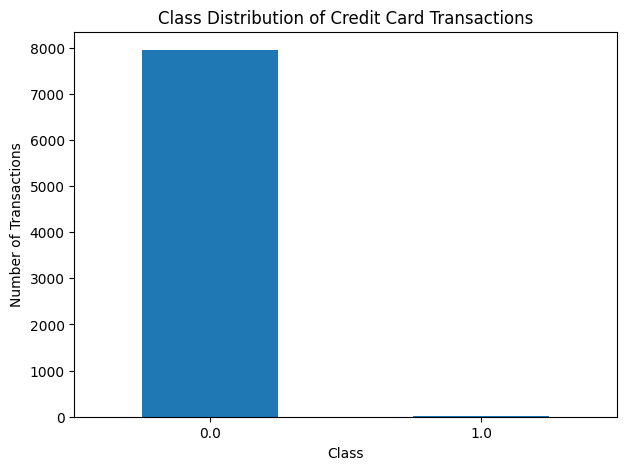

In [10]:
plt.figure(figsize=(7, 5))

class_counts.plot(kind='bar')

plt.title('Class Distribution of Credit Card Transactions')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

### Class Imbalance Observation

The target variable is highly imbalanced. The majority of transactions belong to Class 0 (legitimate transactions), while only a very small proportion belong to Class 1 (fraudulent transactions).

This imbalance is important because a machine learning model could achieve very high accuracy by mostly predicting the majority class while failing to identify fraudulent transactions.

# Step 6 — Separate features and target

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7973, 30)
Target Shape: (7973,)


# Step 7 — Split the data BEFORE applying SMOTE

In [17]:
X = df.drop('Class', axis=1)
y = df['Class']

In [18]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Remove rows where the target variable is missing
valid_target = y.notna()

X = X.loc[valid_target].copy()
y = y.loc[valid_target].copy()

# Fill missing feature values with the median of each feature
X = X.fillna(X.median())

# Convert target to integer
y = y.astype(int)

print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())
print("\nTarget classes:")
print(y.value_counts())

Missing values in X: 0
Missing values in y: 0

Target classes:
Class
0    7947
1      25
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (6377, 30)
Testing set shape: (1595, 30)

Training class distribution:
Class
0    6357
1      20
Name: count, dtype: int64

Testing class distribution:
Class
0    1590
1       5
Name: count, dtype: int64


# Step 8 — Scale the features

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
scaler.fit_transform(X_train)

array([[ 1.99525704,  1.00231559, -0.38043667, ..., -0.30579052,
        -0.01556643, -0.14773417],
       [-1.29670987, -1.08950764,  0.52756051, ...,  0.11626546,
        -0.71346878,  2.5484391 ],
       [-1.13931134,  0.51676786, -1.33691353, ..., -0.06502619,
         0.18231701,  1.10484057],
       ...,
       [-0.14879147,  1.12708715, -0.80179769, ..., -0.09651939,
         0.0533556 , -0.08978959],
       [ 0.54906063, -1.39915007,  1.74887275, ..., -1.94086916,
        -0.23344538, -0.28776255],
       [-0.93484909,  0.85370156, -0.81531557, ..., -0.14635869,
         0.10250504,  0.49932234]])

In [22]:
scaler.transform(X_test)

array([[ 0.07935848, -1.78026866, -0.45303154, ..., -0.12387222,
        -2.03365853,  0.16994215],
       [ 2.09187792,  0.991665  , -0.35361464, ..., -0.3060272 ,
        -0.02818668, -0.25855513],
       [ 1.88305214, -4.32532116, -6.47469585, ...,  2.76693847,
        -1.31435755, -0.18514473],
       ...,
       [-0.18993327,  0.99110381, -0.13311616, ..., -0.17742324,
         0.03375119, -0.17694158],
       [ 0.59082578, -0.46452424,  1.56458166, ...,  0.44870865,
        -1.25141242,  0.44675945],
       [ 0.4452711 , -0.46241709,  0.12104932, ...,  1.05582761,
         0.9267052 , -0.23744638]])

# Step 9 — Train the baseline model

In [23]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Step 10 — Evaluate the baseline model

In [25]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)

print("Baseline Model Performance")
print("--------------------------")
print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)

Baseline Model Performance
--------------------------
Accuracy : 0.9993730407523511
Precision: 1.0
Recall   : 0.8
F1 Score : 0.8888888888888888


In [26]:
print(classification_report(
    y_test,
    y_pred_baseline,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1590
           1       1.00      0.80      0.89         5

    accuracy                           1.00      1595
   macro avg       1.00      0.90      0.94      1595
weighted avg       1.00      1.00      1.00      1595



In [27]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

print("Baseline Confusion Matrix:")
print(cm_baseline)

Baseline Confusion Matrix:
[[1590    0]
 [   1    4]]


# Step 11 — Apply SMOTE

In [28]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [29]:
print("Original Training Distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original Training Distribution:
Class
0    6357
1      20
Name: count, dtype: int64

After SMOTE:
Class
0    6357
1    6357
Name: count, dtype: int64


# Step 12 — Visualize the balanced training data

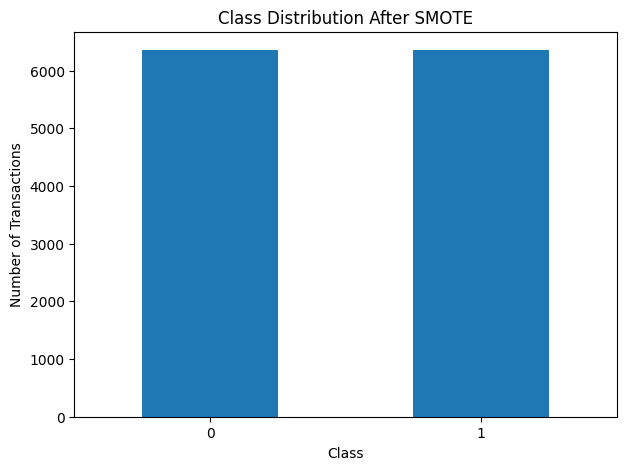

In [30]:
smote_counts = pd.Series(y_train_smote).value_counts()

plt.figure(figsize=(7, 5))

smote_counts.plot(kind='bar')

plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

### SMOTE Observation

SMOTE (Synthetic Minority Over-sampling Technique) increases the representation of the minority class by generating synthetic samples based on existing minority-class observations.

SMOTE was applied only to the training dataset. The test dataset was kept unchanged so that model performance could be evaluated on the original real-world class distribution.

# Step 13 — Train the model after SMOTE

In [31]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [32]:
y_pred_smote = smote_model.predict(X_test_scaled)

# Step 14 — Evaluate the SMOTE model

In [33]:
smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_precision = precision_score(y_test, y_pred_smote, zero_division=0)
smote_recall = recall_score(y_test, y_pred_smote, zero_division=0)
smote_f1 = f1_score(y_test, y_pred_smote, zero_division=0)

print("SMOTE Model Performance")
print("-----------------------")
print("Accuracy :", smote_accuracy)
print("Precision:", smote_precision)
print("Recall   :", smote_recall)
print("F1 Score :", smote_f1)

SMOTE Model Performance
-----------------------
Accuracy : 0.9993730407523511
Precision: 0.8333333333333334
Recall   : 1.0
F1 Score : 0.9090909090909091


In [34]:
print(classification_report(
    y_test,
    y_pred_smote,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1590
           1       0.83      1.00      0.91         5

    accuracy                           1.00      1595
   macro avg       0.92      1.00      0.95      1595
weighted avg       1.00      1.00      1.00      1595



In [35]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

print("SMOTE Confusion Matrix:")
print(cm_smote)

SMOTE Confusion Matrix:
[[1589    1]
 [   0    5]]


# Step 15 — Create the required Before vs After table

In [36]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Baseline Model': [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    'SMOTE Model': [
        smote_accuracy,
        smote_precision,
        smote_recall,
        smote_f1
    ]
})

comparison

,Metric,Baseline Model,SMOTE Model
0,Accuracy,0.999373,0.999373
1,Precision,1.000000,0.833333
2,Recall,0.800000,1.000000
3,F1 Score,0.888889,0.909091


In [37]:
comparison_rounded = comparison.copy()

comparison_rounded[['Baseline Model', 'SMOTE Model']] = (
    comparison_rounded[['Baseline Model', 'SMOTE Model']].round(4)
)

comparison_rounded

,Metric,Baseline Model,SMOTE Model
0,Accuracy,0.9994,0.9994
1,Precision,1.0000,0.8333
2,Recall,0.8000,1.0000
3,F1 Score,0.8889,0.9091


## Why Accuracy Is Misleading

Accuracy can be misleading for highly imbalanced datasets because it measures the percentage of all predictions that are correct without considering how the predictions are distributed across classes.

In this fraud detection dataset, legitimate transactions are far more common than fraudulent transactions. Therefore, a model could predict most transactions as legitimate and still achieve very high accuracy.

However, correctly identifying fraudulent transactions is much more important than simply achieving a high overall accuracy.

For fraud detection, Precision, Recall, and F1-score provide more useful information:

- **Precision** tells us how many transactions predicted as fraud were actually fraudulent.
- **Recall** tells us how many of the actual fraudulent transactions were successfully detected.
- **F1-score** provides a balance between Precision and Recall.

Therefore, accuracy should not be used as the only evaluation metric for this highly imbalanced classification problem.

## Conclusion

The Credit Card Fraud Detection dataset contains a severe class imbalance, with fraudulent transactions representing only a very small portion of the total transactions.

A baseline Logistic Regression model was first trained on the original imbalanced training data. The model was then retrained after applying SMOTE to the training set.

The results show how handling class imbalance can change Precision, Recall, and F1-score. Although accuracy is useful as a general metric, it does not adequately describe the model's ability to detect the minority fraud class.

For fraud detection, Recall is particularly important because missing fraudulent transactions can be costly. Precision is also important because too many false fraud alerts can negatively affect legitimate customers. F1-score provides a useful balance between these two metrics.

SMOTE therefore provides a practical approach for improving the model's ability to learn from the minority class while keeping the test set unchanged for a fair evaluation.